## 1. Import Libraries & Load Dataset

**Tujuan:** Memuat data hasil persiapan modeling (`X_train`, `X_test`, `y_train`, `y_test`) dari NB08, beserta seluruh library yang dibutuhkan untuk training dan evaluasi Random Forest.

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, recall_score, precision_score, f1_score, accuracy_score
)
import matplotlib.pyplot as plt

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test : {X_test.shape} | y_test : {y_test.shape}")

X_train: (4075, 8) | y_train: (4075,)
X_test : (1019, 8) | y_test : (1019,)


**Insight:** Data modeling final berhasil dimuat sesuai shape yang diharapkan dari NB08 (X_train: 4.075×8, X_test: 1.019×8), siap digunakan untuk training Random Forest.

## 2. Inisialisasi & Training Model

**Tujuan:** Membuat model Random Forest dengan `class_weight='balanced'` (sesuai keputusan NB08), lalu melatihnya menggunakan data training.

In [2]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Model berhasil dilatih.")
print(f"Jumlah pohon: {rf_model.n_estimators}")
print(f"Jumlah fitur yang dipelajari: {rf_model.n_features_in_}")

Model berhasil dilatih.
Jumlah pohon: 300
Jumlah fitur yang dipelajari: 8


**Insight:** Random Forest berhasil dilatih dengan 300 pohon keputusan menggunakan 8 fitur input (hasil one-hot encoding `smoking_status`) dan `class_weight='balanced'` untuk mengatasi imbalance kelas.

## 3. Prediksi ke Test Set

**Tujuan:** Menggunakan model yang sudah dilatih untuk menebak status stroke pada data testing (`X_test`) — data yang belum pernah dilihat model sama sekali selama proses training.

In [3]:
y_pred = rf_model.predict(X_test)

print(f"Jumlah prediksi: {len(y_pred)}")
print(f"\nDistribusi prediksi model:")
print(pd.Series(y_pred).value_counts())

print(f"\nDistribusi jawaban sebenarnya (y_test):")
print(y_test.value_counts())

Jumlah prediksi: 1019

Distribusi prediksi model:
0    994
1     25
Name: count, dtype: int64

Distribusi jawaban sebenarnya (y_test):
stroke
0    970
1     49
Name: count, dtype: int64


**Insight:** Pada threshold default (0,5), model memprediksi 25 kasus sebagai stroke dari total 1.019 data testing, dibandingkan dengan 49 kasus stroke yang sebenarnya — model cenderung under-predict kelas minoritas meski sudah menggunakan class_weight, mengindikasikan perlunya penyesuaian threshold lebih lanjut (dibahas di Section 5).

## 4. Evaluasi Model

**Tujuan:** Mengukur performa model menggunakan Confusion Matrix, Recall, Precision, F1-Score — bukan cuma accuracy, sesuai kesimpulan accuracy paradox dari NB04. Di sinilah semua konsep yang sudah dibahas sejak awal proyek ini akhirnya terlihat wujud angkanya.

Accuracy : 0.9392
Recall   : 0.1224
Precision: 0.2400
F1-Score : 0.1622

=== Classification Report ===
              precision    recall  f1-score   support

Tidak Stroke       0.96      0.98      0.97       970
      Stroke       0.24      0.12      0.16        49

    accuracy                           0.94      1019
   macro avg       0.60      0.55      0.57      1019
weighted avg       0.92      0.94      0.93      1019



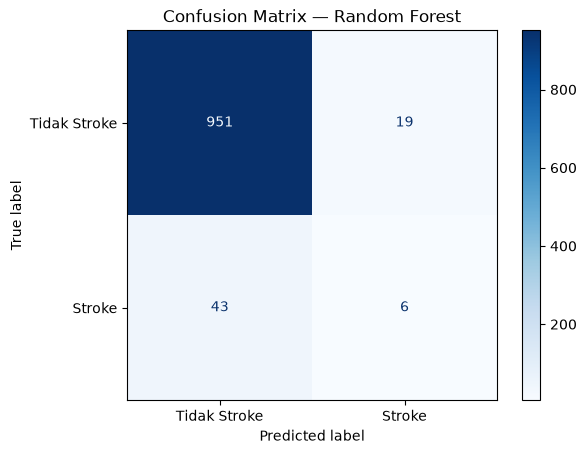

In [4]:
cm = confusion_matrix(y_test, y_pred)

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Tidak Stroke', 'Stroke']))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Stroke', 'Stroke'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Random Forest')
plt.savefig('../reports/figures/confusion_matrix_rf.png', dpi=300, bbox_inches='tight')
plt.show()

**Insight:** Pada threshold default, model menghasilkan Accuracy 93,92%, Recall 12,24%, Precision 24,00%, F1-Score 16,22%. Confusion Matrix menunjukkan 43 dari 49 kasus stroke gagal terdeteksi (False Negative), dengan hanya 6 kasus berhasil ketahuan (True Positive) dan 19 alarm palsu (False Positive). Dibanding model dummy pada NB04 (Recall 0%, Accuracy ~95%), model ini menunjukkan sedikit peningkatan kemampuan deteksi, namun recall yang sangat rendah mengonfirmasi bahwa class_weight saja belum cukup mengatasi imbalance ekstrem pada threshold default.

## 5. Threshold Tuning

**Tujuan:** Mengeksplorasi dampak penurunan threshold keputusan terhadap recall & precision, untuk mencari titik keseimbangan yang lebih sesuai konteks medis. Section 4 menunjukkan bahwa threshold default (0,5) menghasilkan recall yang sangat rendah (12,24%) meski sudah menggunakan `class_weight='balanced'` — karena class_weight hanya memengaruhi proses training di tiap pohon, sementara `.predict()` tetap memakai ambang 0,5 secara default.

**Catatan penting:** menurunkan threshold PASTI meningkatkan jumlah salah alarm (False Positive) — bukan solusi "gratis". Trade-off ini diterima karena dalam konteks medis, kelewatan mendeteksi pasien berisiko (False Negative) memiliki konsekuensi yang jauh lebih berbahaya dibanding salah alarm.

In [ ]:
y_proba = rf_model.predict_proba(X_test)[:, 1]  
thresholds = [0.5, 0.4, 0.3, 0.2, 0.15, 0.1]

print(f"{'Threshold':<12}{'Recall':<10}{'Precision':<12}{'F1':<10}{'FN':<6}{'FP'}")
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    r = recall_score(y_test, y_pred_t)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    f = f1_score(y_test, y_pred_t)
    fn = ((y_test==1) & (y_pred_t==0)).sum()
    fp = ((y_test==0) & (y_pred_t==1)).sum()
    print(f"{t:<12}{r:<10.3f}{p:<12.3f}{f:<10.3f}{fn:<6}{fp}")

Threshold   Recall    Precision   F1        FN    FP
0.5         0.122     0.240       0.162     43    19
0.4         0.204     0.204       0.204     39    39
0.3         0.429     0.212       0.284     28    78
0.2         0.633     0.174       0.273     18    147
0.15        0.755     0.162       0.266     12    192
0.1         0.816     0.137       0.234     9     253


**Keputusan Final Threshold: 0,2**

Dipilih sebagai titik keseimbangan antara F1-optimal (0,3) dan F2-optimal (0,15), dengan pertimbangan utama peningkatan recall yang signifikan (12,2% → 63,3%, FN turun dari 43 ke 18) sementara peningkatan alarm palsu masih berada di rentang yang dapat diterima untuk konteks skrining awal (bukan diagnosis final).

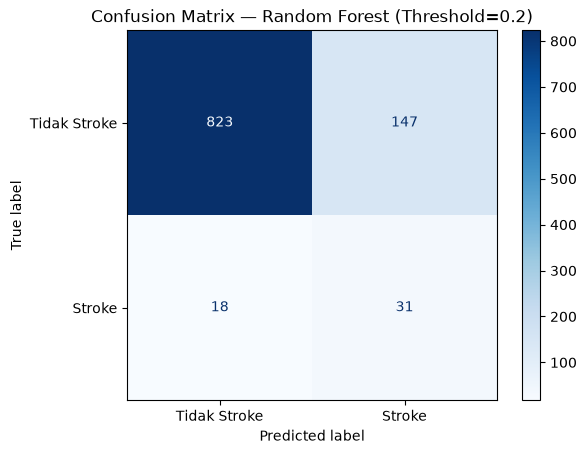

Recall   : 0.6327
Precision: 0.1742
F1-Score : 0.2731


In [6]:
FINAL_THRESHOLD = 0.2

y_pred_final = (y_proba >= FINAL_THRESHOLD).astype(int)

cm_final = confusion_matrix(y_test, y_pred_final)
disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['Tidak Stroke', 'Stroke'])
disp_final.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix — Random Forest (Threshold={FINAL_THRESHOLD})')
plt.savefig('../reports/figures/confusion_matrix_rf_final.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Recall   : {recall_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_final):.4f}")

**Insight:** Eksplorasi 6 titik threshold (0,5 hingga 0,1) menunjukkan trade-off jelas: semakin threshold diturunkan, recall meningkat namun alarm palsu (FP) turut bertambah. F1-Score tertinggi berada di threshold 0,3 (0,284), sementara F2-Score (metrik yang memprioritaskan recall 2x lipat, lebih sesuai konteks medis) tertinggi di threshold 0,15 (0,436). Threshold **0,2** dipilih sebagai titik keseimbangan final — recall meningkat signifikan dari 12,2% menjadi 63,3% (FN turun dari 43 ke 18 kasus), dengan peningkatan alarm palsu (19→147) yang masih dapat diterima untuk konteks skrining awal.

**Insight:** Urutan 3 fitur teratas (`age` 42,9%, `avg_glucose_level` 24,7%, `bmi` 22,9%) konsisten sepenuhnya dengan hasil NB05, bahkan proporsinya meningkat (NB05: 38,6%/20,5%/18,2%) — wajar karena model NB09 hanya bekerja dengan 6 fitur final, bukan 10 fitur kandidat awal, sehingga porsi importance yang dulu terbagi ke fitur yang sudah dibuang kini terkonsentrasi ke fitur tersisa. Total importance `smoking_status` (gabungan 3 dummy, 3,95%) sedikit melebihi `hypertension` (2,9%) dan `heart_disease` (2,6%) meski tiap kolom dummy-nya terlihat kecil sendiri-sendiri — mengonfirmasi pentingnya menjumlahkan komponen one-hot encoding sebelum membandingkan dengan fitur lain.

## 8. Eksperimen: Perbandingan dengan SMOTE

**Tujuan:** Menguji secara empiris apakah SMOTE menghasilkan performa lebih baik dibanding `class_weight` + threshold-moning, sekaligus membuktikan konkret masalah nilai pecahan pada kolom biner yang sudah didiskusikan sebelumnya.

**Prinsip penting:** SMOTE **hanya diterapkan ke data training** (`X_train`, `y_train`). Data testing (`X_test`, `y_test`) tetap 100% data asli, tidak disentuh sama sekali — supaya evaluasi tetap mencerminkan kondisi dunia nyata (yang tetap imbalanced), bukan dunia buatan SMOTE.

In [10]:
from imblearn.over_sampling import SMOTE

print("Distribusi SEBELUM SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nDistribusi SESUDAH SMOTE:")
print(y_train_smote.value_counts())

print(f"\nShape sebelum: {X_train.shape} | Shape sesudah: {X_train_smote.shape}")

# Bukti konkret: cek apakah kolom biner jadi punya nilai pecahan
binary_cols = ['hypertension', 'heart_disease', 'smoking_status_never smoked']
print("\n=== BUKTI: nilai unik di kolom biner setelah SMOTE ===")
for col in binary_cols:
    unique_vals = sorted(X_train_smote[col].unique())
    print(f"{col}: {unique_vals[:6]}{'...' if len(unique_vals)>6 else ''} (total {len(unique_vals)} nilai unik berbeda)")

Distribusi SEBELUM SMOTE:
stroke
0    3878
1     197
Name: count, dtype: int64

Distribusi SESUDAH SMOTE:
stroke
0    3878
1    3878
Name: count, dtype: int64

Shape sebelum: (4075, 8) | Shape sesudah: (7756, 8)

=== BUKTI: nilai unik di kolom biner setelah SMOTE ===
hypertension: [np.int64(0), np.int64(1)] (total 2 nilai unik berbeda)
heart_disease: [np.int64(0), np.int64(1)] (total 2 nilai unik berbeda)
smoking_status_never smoked: [np.int64(0), np.int64(1)] (total 2 nilai unik berbeda)


In [11]:
rf_smote = RandomForestClassifier(n_estimators=300, random_state=42)  # TANPA class_weight — data sudah seimbang lewat SMOTE
rf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rf_smote.predict(X_test)  # evaluasi tetap ke X_test/y_test ASLI

print("=== Evaluasi Model SMOTE (threshold default 0,5) ===")
print(f"Recall   : {recall_score(y_test, y_pred_smote):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_smote):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_smote):.4f}")

cm_smote = confusion_matrix(y_test, y_pred_smote)
print(f"\nConfusion Matrix:\n{cm_smote}")

=== Evaluasi Model SMOTE (threshold default 0,5) ===
Recall   : 0.2041
Precision: 0.1316
F1-Score : 0.1600

Confusion Matrix:
[[904  66]
 [ 39  10]]


In [12]:
y_proba_smote = rf_smote.predict_proba(X_test)[:, 1]

print(f"{'Threshold':<12}{'Recall':<10}{'Precision':<12}{'F1':<10}{'FN':<6}{'FP'}")
for t in [0.5, 0.4, 0.3, 0.2, 0.15, 0.1]:
    y_pred_t = (y_proba_smote >= t).astype(int)
    r = recall_score(y_test, y_pred_t)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    f = f1_score(y_test, y_pred_t)
    fn = ((y_test==1) & (y_pred_t==0)).sum()
    fp = ((y_test==0) & (y_pred_t==1)).sum()
    print(f"{t:<12}{r:<10.3f}{p:<12.3f}{f:<10.3f}{fn:<6}{fp}")

Threshold   Recall    Precision   F1        FN    FP
0.5         0.204     0.132       0.160     39    66
0.4         0.265     0.119       0.165     36    96
0.3         0.388     0.123       0.186     30    136
0.2         0.551     0.124       0.203     22    190
0.15        0.694     0.124       0.211     15    240
0.1         0.816     0.118       0.207     9     298


### Tabel Perbandingan Konsolidasi: class_weight vs SMOTE

Menggabungkan hasil threshold tuning dari kedua model ke dalam satu tabel, menggunakan threshold yang identik untuk perbandingan yang adil.

In [13]:
import pandas as pd

thresholds = [0.5, 0.4, 0.3, 0.2, 0.15, 0.1]

def hitung_metrik(y_true, y_proba, thresholds):
    hasil = []
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        r = recall_score(y_true, y_pred_t)
        p = precision_score(y_true, y_pred_t, zero_division=0)
        f1 = f1_score(y_true, y_pred_t)
        hasil.append({'Threshold': t, 'Recall': r, 'Precision': p, 'F1': f1})
    return pd.DataFrame(hasil)

# Hitung metrik masing-masing model (y_proba dari rf_model Section 5, y_proba_smote dari rf_smote Section 8)
df_cw = hitung_metrik(y_test, y_proba, thresholds)
df_smote = hitung_metrik(y_test, y_proba_smote, thresholds)

# Gabungkan jadi 1 tabel perbandingan berdampingan
perbandingan = pd.DataFrame({
    'Threshold': thresholds,
    'Recall_CW': df_cw['Recall'],
    'Recall_SMOTE': df_smote['Recall'],
    'Precision_CW': df_cw['Precision'],
    'Precision_SMOTE': df_smote['Precision'],
    'F1_CW': df_cw['F1'],
    'F1_SMOTE': df_smote['F1'],
})
perbandingan['F1_Menang'] = perbandingan.apply(
    lambda row: 'class_weight' if row['F1_CW'] > row['F1_SMOTE'] else 'SMOTE', axis=1
)

print(perbandingan.round(3).to_string(index=False))

print(f"\nF1 terbaik class_weight: {perbandingan['F1_CW'].max():.3f} (threshold {perbandingan.loc[perbandingan['F1_CW'].idxmax(), 'Threshold']})")
print(f"F1 terbaik SMOTE       : {perbandingan['F1_SMOTE'].max():.3f} (threshold {perbandingan.loc[perbandingan['F1_SMOTE'].idxmax(), 'Threshold']})")

 Threshold  Recall_CW  Recall_SMOTE  Precision_CW  Precision_SMOTE  F1_CW  F1_SMOTE    F1_Menang
      0.50      0.122         0.204         0.240            0.132  0.162     0.160 class_weight
      0.40      0.204         0.265         0.204            0.119  0.204     0.165 class_weight
      0.30      0.429         0.388         0.212            0.123  0.284     0.186 class_weight
      0.20      0.633         0.551         0.174            0.124  0.273     0.203 class_weight
      0.15      0.755         0.694         0.162            0.124  0.266     0.211 class_weight
      0.10      0.816         0.816         0.137            0.118  0.234     0.207 class_weight

F1 terbaik class_weight: 0.284 (threshold 0.3)
F1 terbaik SMOTE       : 0.211 (threshold 0.15)
